# <font color=#0099CC>**Baseline 2: Regresión OLS Multisalida**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Se ajusta una **regresión lineal** multisalida: se aplana `X` de `(N, v_in, 23)` a `(N, v_in \times 23)` y se estiman pesos por mínimos cuadrados. Es el baseline más exigente antes de las redes neuronales; si un modelo profundo no mejora esto, conviene revisar datos o capacidad.

Trabaja sobre **log-retornos diarios** — el MAE se reporta en esa escala (≈ 1e-2).

**Salidas generadas**:

- `08_results/tablas/baseline_lineal_resultados.csv`
- `08_results/matrices/heatmap_baseline_lineal_*.png`
- `08_results/graficas_combinaciones/lineal_coef_*.png`
- `08_results/graficas_combinaciones/lineal_overfitting.png`


## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura la raíz del repositorio (`BASE`), el acceso a Google Drive cuando el cuaderno corre en Colab, y se inserta `01_src_compartido` en `sys.path` para importar las utilidades compartidas sin duplicar código.


In [1]:
# ── Detección automática de entorno ─────────────────────────────────────────
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    # En local: ruta a la carpeta raíz del proyecto clonada/descargada
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX
> SRC     : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías, scikit-learn y módulos compartidos**</font>

Además del stack numérico habitual, se importan `LinearRegression` y `MultiOutputRegressor`. Las utilidades de datos y métricas se cargan desde `01_src_compartido` y se fija `metrics_utils.BASE_DRIVE` antes de guardar figuras o CSV.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from pathlib import Path
from IPython.display import clear_output
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import plot_heatmap, plot_comparativa_vout, guardar_resultados

## <font color=#0099CC>**3. DESCARGA DE DATOS**</font>

### <font color=#336699>**3.1. Log-retornos diarios de los 23 activos**</font>

Se obtiene la matriz `(T, 23)` de **log-retornos diarios** mediante `load_data`, usando la lista `TICKERS` literal del fichero del profesor. El default `use_log_returns=True` ya devuelve log-retornos (escala que exige el enunciado).


In [3]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

> Datos : 16,197 días × 23 activos
> Rango : 1962-01-03 → 2026-05-12


## <font color=#0099CC>**4. MODELO LINEAL**</font>

### <font color=#336699>**4.1. Aplanado, regresor y diagnósticos**</font>

Definición de `flatten_X`, construcción del regresor multisalida, conteo de parámetros teóricos y utilidad para graficar la norma de coeficientes por día de entrada (interpretabilidad frente a ventanas largas).


In [4]:
def flatten_X(X):
    """(N, v_in, Ch) → (N, v_in*Ch)"""
    return X.reshape(X.shape[0], -1)

def build_linear_model():
    """Un regresor lineal independiente por activo."""
    return MultiOutputRegressor(LinearRegression(), n_jobs=-1)

def count_params_linear(v_in, n_assets=23):
    """n_assets * (v_in * n_assets + 1)"""
    return n_assets * (v_in * n_assets + 1)

def plot_coef_importancia(model, v_in, v_out, n_assets=23, save=True):
    """Importancia por día de entrada: norma L2 de coeficientes."""
    coefs    = np.array([e.coef_ for e in model.estimators_])
    coefs_3d = coefs.reshape(n_assets, v_in, n_assets)
    imp_dia  = np.linalg.norm(coefs_3d, axis=(0, 2))

    fig, ax = plt.subplots(figsize=(max(6, v_in // 2), 3))
    ax.bar(range(v_in), imp_dia)
    ax.set_title(f'Importancia por día — V_in={v_in}, V_out={v_out}')
    ax.set_xlabel('Día (0 = más antiguo)')
    ax.set_ylabel('Norma L2 coeficientes')
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()

    if save:
        ruta = Path(BASE) / '08_results' / 'graficas_combinaciones' / f'lineal_coef_vin{v_in}_vout{v_out}.png'
        ruta.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(ruta, dpi=150)
    return fig

## <font color=#0099CC>**5. EVALUACIÓN 4×4**</font>

### <font color=#336699>**5.1. Entrenamiento y métricas por combinación**</font>

Bucle sobre todas las parejas (V_in, V_out) \in \{5,10,30,90\} \times \{1,5,30,90\}. Para cada par: entrenamiento sobre train (semilla de competición = 42), MAE en train, val y test, figura de coeficientes y fila del CSV maestro.


In [5]:
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida  = [1, 5, 30, 90]
combos     = list(product(ventanas_entrada, ventanas_salida))
resultados = []

N, BAR_LEN = len(combos), 30

for k, (v_in, v_out) in enumerate(combos, 1):
    filled = int(BAR_LEN * k / N)
    bar    = '█' * filled + '░' * (BAR_LEN - filled)
    clear_output(wait=True)
    print(f'> Evaluación 4x4  [{bar}]  {k:>2}/{N}  '
          f'(V_in={v_in:>2}, V_out={v_out:>2})')

    X, Y = create_dataset(data, v_in, v_out)
    X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y)

    X_tr_f   = flatten_X(X_tr)
    X_val_f  = flatten_X(X_val)
    X_test_f = flatten_X(X_test)

    model = build_linear_model()
    model.fit(X_tr_f, Y_tr)

    mae_train = float(np.mean(np.abs(model.predict(X_tr_f)   - Y_tr)))
    mae_val   = float(np.mean(np.abs(model.predict(X_val_f)  - Y_val)))
    mae_test  = float(np.mean(np.abs(model.predict(X_test_f) - Y_test)))
    n_params  = count_params_linear(v_in)

    plot_coef_importancia(model, v_in, v_out, save=True)
    plt.close('all')

    resultados.append({
        'modelo':   'lineal',
        'v_in':     v_in,
        'v_out':    v_out,
        'n_params': n_params,
        'mae_train': mae_train,
        'mae_val':   mae_val,
        'mae_test':  mae_test,
    })

clear_output(wait=True)
print(f'> Evaluación 4x4 completada  [{"█" * BAR_LEN}]  {N}/{N}')
pd.DataFrame(resultados).round(4)

> Evaluación 4x4 completada  [██████████████████████████████]  16/16


,modelo,v_in,v_out,n_params,mae_train,mae_val,mae_test
0,lineal,5,1,2668,0.0116,0.0119,0.0119
1,lineal,5,5,2668,0.0053,0.0054,0.0055
2,lineal,5,30,2668,0.0022,0.0022,0.0022
3,lineal,5,90,2668,0.0012,0.0012,0.0013
4,lineal,10,1,5313,0.0116,0.0119,0.0119
5,lineal,10,5,5313,0.0053,0.0056,0.0055
6,lineal,10,30,5313,0.0021,0.0022,0.0022
7,lineal,10,90,5313,0.0012,0.0013,0.0013
8,lineal,30,1,15893,0.0115,0.0121,0.0123
9,lineal,30,5,15893,0.0053,0.0055,0.0056


## <font color=#0099CC>**6. PERSISTENCIA DE RESULTADOS**</font>

### <font color=#336699>**6.1. Exportación CSV estándar**</font>

Se guarda el CSV del modelo lineal con el mismo esquema de columnas que el resto de experimentos del repositorio.


In [6]:
df_resultados = guardar_resultados(resultados, 'baseline_lineal')
display(df_resultados)

,modelo,v_in,v_out,n_params,mae_train,mae_val,mae_test
0,lineal,5,1,2668,0.011597,0.011860,0.011912
1,lineal,5,5,2668,0.005326,0.005395,0.005525
2,lineal,5,30,2668,0.002166,0.002161,0.002160
3,lineal,5,90,2668,0.001232,0.001221,0.001261
4,lineal,10,1,5313,0.011584,0.011943,0.011904
5,lineal,10,5,5313,0.005306,0.005578,0.005463
6,lineal,10,30,5313,0.002148,0.002244,0.002166
7,lineal,10,90,5313,0.001227,0.001253,0.001251
8,lineal,30,1,15893,0.011502,0.012144,0.012321
9,lineal,30,5,15893,0.005256,0.005492,0.005580


## <font color=#0099CC>**7. MAPAS DE CALOR (MAE)**</font>

### <font color=#336699>**7.1. Heatmaps por partición**</font>

Se generan matrices 4×4 para **train**, **val** y **test**, comparables con el resto de arquitecturas del taller.


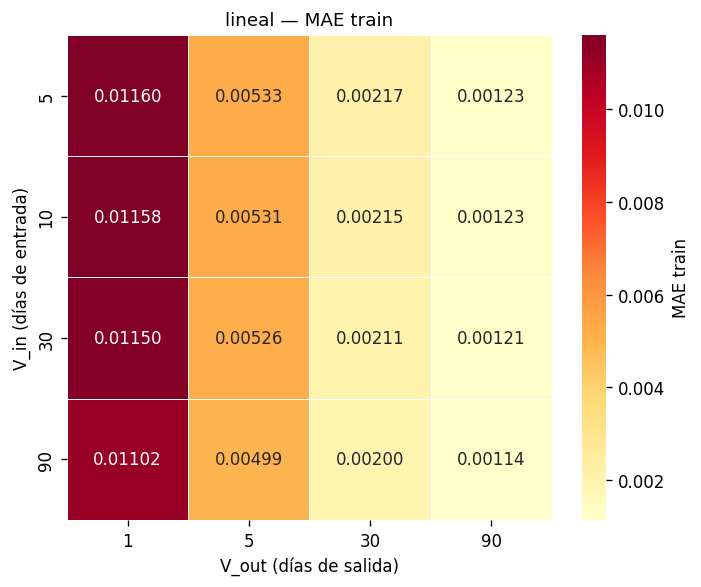

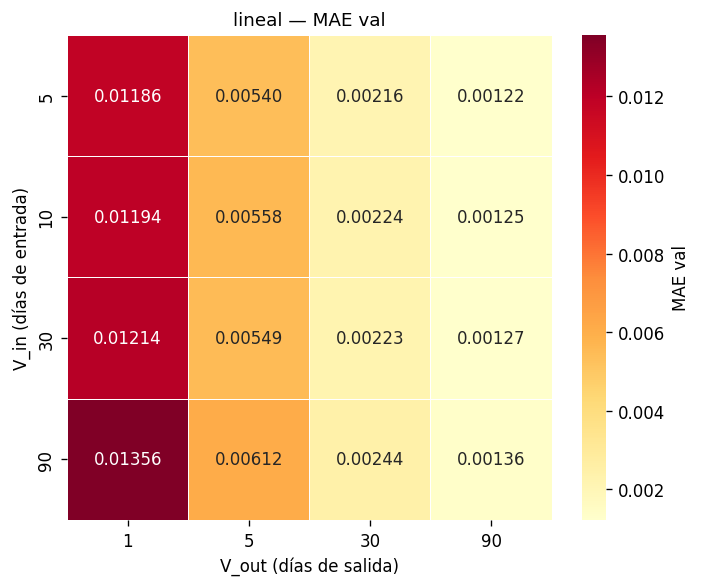

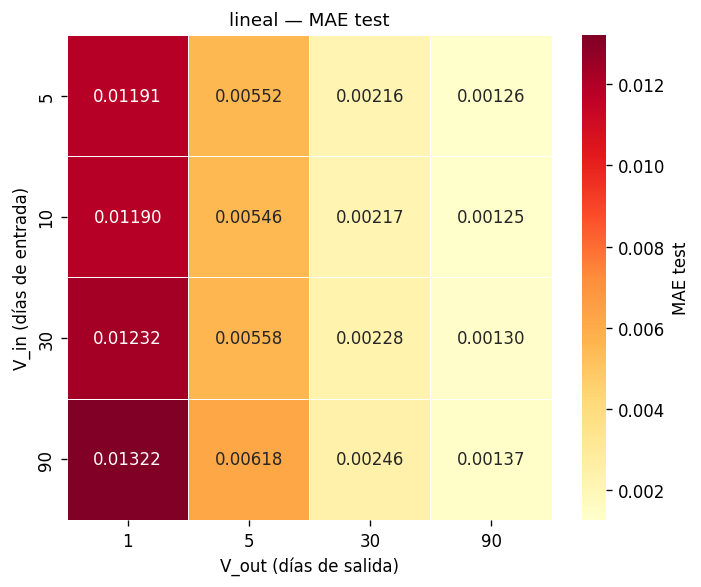

train                             val                          \
v_out             1       5       30      90      1       5       30      90   
V_in \ V_out                                                                   
5             0.0116  0.0053  0.0022  0.0012  0.0119  0.0054  0.0022  0.0012   
10            0.0116  0.0053  0.0021  0.0012  0.0119  0.0056  0.0022  0.0013   
30            0.0115  0.0053  0.0021  0.0012  0.0121  0.0055  0.0022  0.0013   
90            0.0110  0.0050  0.0020  0.0011  0.0136  0.0061  0.0024  0.0014   

                test                          
v_out             1       5       30      90  
V_in \ V_out                                  
5             0.0119  0.0055  0.0022  0.0013  
10            0.0119  0.0055  0.0022  0.0013  
30            0.0123  0.0056  0.0023  0.0013  
90            0.0132  0.0062  0.0025  0.0014

In [7]:
for split in ['train', 'val', 'test']:
    plot_heatmap(df_resultados, 'lineal', split=split, save=True)
    plt.show()

heatmap_df = pd.concat(
    {split: df_resultados.pivot(index='v_in', columns='v_out',
                                values=f'mae_{split}')
     for split in ['train', 'val', 'test']},
    axis=1,
).round(4)
heatmap_df.index.name = 'V_in \\ V_out'
heatmap_df

## <font color=#0099CC>**9. TABLA RESUMEN**</font>

### <font color=#336699>**9.1. Mejor V_in por V_out en test**</font>

Tabla pivote de MAE test y localización del mejor número de días de entrada para cada horizonte de salida en el baseline lineal.


In [9]:
print('> MAE Test: Baseline Lineal (escala log-retornos)')
pivot = (df_resultados
         .pivot(index='v_in', columns='v_out', values='mae_test')
         .round(4))
pivot.index.name   = 'V_in \\ V_out'
pivot.columns.name = None
display(pivot)

print('> Mejor V_in por cada V_out:')
for v_out, best_v_in in df_resultados.loc[
        df_resultados.groupby('v_out')['mae_test'].idxmin(),
        ['v_out', 'v_in']].itertuples(index=False):
    print(f'  > V_out = {v_out:>2} → V_in = {best_v_in}')


> MAE Test: Baseline Lineal (escala log-retornos)


,1,5,30,90
V_in \ V_out,,,,
5,0.0119,0.0055,0.0022,0.0013
10,0.0119,0.0055,0.0022,0.0013
30,0.0123,0.0056,0.0023,0.0013
90,0.0132,0.0062,0.0025,0.0014


> Mejor V_in por cada V_out:
  > V_out =  1 → V_in = 10
  > V_out =  5 → V_in = 10
  > V_out = 30 → V_in = 5
  > V_out = 90 → V_in = 10


## <font color=#0099CC>**9. EVALUACIÓN INVESTIGACIÓN (frac-diff + split temporal)**</font>

Sección paralela a la 5: replica el bucle 4×4 sobre los **mismos inputs que usan los notebooks de `07_investigacion_ldp/`** — frac-diff de `log(precio)` con `d = D_FRAC_INV = 0.40` (FFD, López de Prado 2018) y partición temporal con embargo `V_in + V_out` (Purged Split, LdP cap. 7) vía `get_partitions_temporal`. **No** se aplica scaler (el predictor depende de la escala de X y Y; ambos quedan en frac-diff).

> El MAE resultante está en **unidades de frac-diff**, no en log-retornos. Es internamente coherente con el de los modelos de investigación pero **no comparable** en valor absoluto con la sección 5. Se guarda en un CSV separado (`baseline_lineal_inv_resultados.csv`) que los notebooks 07 consultan automáticamente (`metrics_utils.cargar_baselines_combo(..., scope="inv")`).

### <font color=#336699>**9.1. Carga de datos frac-diff**</font>

`load_data(d_frac=D_FRAC_INV, verbose=True)` aplica FFD sobre `log(precio)` y descarta las primeras `L-1` filas del histórico (truncación del kernel).

In [ ]:
from dataset_utils import D_FRAC_INV, get_partitions_temporal

data_inv, df_inv = load_data(d_frac=D_FRAC_INV, verbose=True)
print(f'> Datos (inv) : {data_inv.shape[0]:,} días × {data_inv.shape[1]} activos  '
      f'(escala: frac-diff, d={D_FRAC_INV})')
print(f'> Rango       : {df_inv.index[0].date()} → {df_inv.index[-1].date()}')

### <font color=#336699>**9.2. Evaluación 4×4 con split temporal y embargo**</font>

Mismo recorrido `V_in × V_out` que en la sección 5, pero usando `get_partitions_temporal(X, Y, v_in=v_in, v_out=v_out)` — embargo automático `V_in + V_out` entre train / val / test.

In [ ]:
resultados_inv = []
N, BAR_LEN = len(combos), 30

for k, (v_in, v_out) in enumerate(combos, 1):
    filled = int(BAR_LEN * k / N)
    bar    = '█' * filled + '░' * (BAR_LEN - filled)
    clear_output(wait=True)
    print(f'> Evaluación 4x4 (inv: frac-diff + temporal)  [{bar}]  {k:>2}/{N}  '
          f'(V_in={v_in:>2}, V_out={v_out:>2})')

    X, Y = create_dataset(data_inv, v_in, v_out)
    X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions_temporal(
        X, Y, v_in=v_in, v_out=v_out,
    )

    X_tr_f   = flatten_X(X_tr)
    X_val_f  = flatten_X(X_val)
    X_test_f = flatten_X(X_test)

    model = build_linear_model()
    model.fit(X_tr_f, Y_tr)

    mae_train = float(np.mean(np.abs(model.predict(X_tr_f)   - Y_tr)))
    mae_val   = float(np.mean(np.abs(model.predict(X_val_f)  - Y_val)))
    mae_test  = float(np.mean(np.abs(model.predict(X_test_f) - Y_test)))
    n_params  = count_params_linear(v_in)

    resultados_inv.append({
        'modelo':    'lineal',
        'v_in':      v_in,
        'v_out':     v_out,
        'n_params':  n_params,
        'mae_train': mae_train,
        'mae_val':   mae_val,
        'mae_test':  mae_test,
    })

clear_output(wait=True)
print(f'> Evaluación 4x4 (inv) completada  [{"█" * BAR_LEN}]  {N}/{N}')
pd.DataFrame(resultados_inv).round(5)

### <font color=#336699>**9.3. Persistencia en CSV separado**</font>

CSV con sufijo `_inv` (`baseline_lineal_inv_resultados.csv`) — esquema idéntico al de la sección 6. Lo recogen automáticamente los notebooks `07_investigacion_ldp/` vía `metrics_utils.cargar_baselines_combo(..., scope="inv")`, que dispatcha por `nombre_modelo.startswith("inv_")`.

In [ ]:
df_resultados_inv = guardar_resultados(resultados_inv, 'baseline_lineal_inv')
print('> Resultados (inv) guardados : 08_results/tablas/baseline_lineal_inv_resultados.csv')

### <font color=#336699>**9.4. Tabla resumen MAE test (escala frac-diff)**</font>

Pivote `V_in × V_out` del MAE en test en la nueva escala. Sirve de referencia directa para los modelos `inv_*` del taller.

In [ ]:
print('> MAE Test: Baseline Lineal (escala frac-diff, split temporal)')
pivot_inv = (df_resultados_inv
             .pivot(index='v_in', columns='v_out', values='mae_test')
             .round(5))
pivot_inv.index.name   = 'V_in \\ V_out'
pivot_inv.columns.name = None
pivot_inv